# Task: Correlation

**Student Name:** Sébastien Bagdasarianz  
**Country:** Colombia  
**Semester term:** HS26

In [ ]:
from pathlib import Path

_WORKSPACE_ROOT = next(
    (
        parent
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "gbsv_mc1" / "data").is_dir()
    ),
    None,
)
if _WORKSPACE_ROOT is None:
    raise FileNotFoundError("Could not locate gbsv_mc1/data from the current directory")
DATA_DIR = _WORKSPACE_ROOT / "gbsv_mc1" / "data"

## Day 6 – Data & Domain


### Use Case

In Colombian passive acoustic monitoring, autonomous recorders produce long bird-audio streams that conservation teams need to search for target vocalizations. Correlation supports two related but distinct tasks: estimating local periodic structure within a call and locating a known call template in a recording, reducing the need for manual screening across remote habitats.

### Problem Statement

This investigation tests whether autocorrelation can reveal short-lag periodic structure in a Great Kiskadee call and whether normalized cross-correlation can localize a supplied call template in a 10-second Colombian field recording. Strong background variation, non-stationary calls, or a template that differs in duration, amplitude envelope, or timing can obscure peaks and cause false localization; results must therefore be checked against the known sample position and interpreted as a single-recording demonstration.

### Experimental Objective

The objective is to characterize short-term repeating structure within a representative bird call and evaluate how reliably its acoustic template can be found in the surrounding recording. The analysis distinguishes periodicity measurement from event localization and tests whether the latter remains stable under shorter templates, additive noise, and amplitude changes.

### Data Definition, Source, and Visualization

The signal is a 10 s, mono, 48 kHz excerpt of normalized sound-pressure amplitude from the PteroSet v5 Great Kiskadee recording `P5-G022_04-13_tlapse.wav`, Pijavay, Magdalena, Colombia. The companion 2 s template is the exact excerpt beginning at 0.80 s in this stream, so its known localization is 0.80 s rather than an independent later call. The signal is suitable for demonstrating local autocorrelation and cross-correlation localization, but exact reuse of the template makes the baseline a controlled software check rather than an independent biological detection trial. The dataset is curated with species annotations and recording metadata; both audio files are provided in this project’s `data/` folder.

<span style="background-color: #eeeeee;">*Guideline: Visualize a representative excerpt of your signal. If the data are audio-based, additionally provide a playable audio segment. All visualizations must include clearly labeled axes and the correct units.*</span>


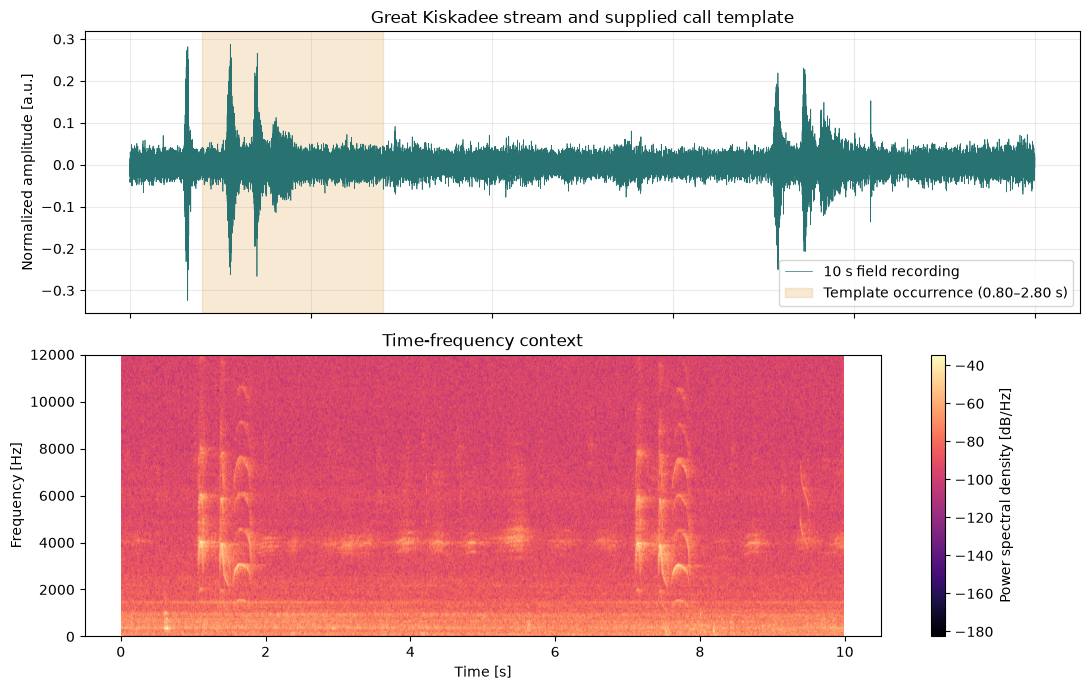

Stream: 10.0 s at 48,000 Hz
Template: 2.0 s at 48,000 Hz
Playable stream excerpt:


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import IPython.display as ipd


data_dir = DATA_DIR
stream, sample_rate = sf.read(data_dir / "segment_10s_48khz.wav")
template, template_rate = sf.read(data_dir / "call_template_2s_48khz.wav")
if stream.ndim == 2:
    stream = stream.mean(axis=1)
if template.ndim == 2:
    template = template.mean(axis=1)
if sample_rate != template_rate:
    raise ValueError("Stream and template sample rates must match")
time = np.arange(len(stream)) / sample_rate

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(time, stream, color="#287271", linewidth=0.5, label="10 s field recording")
axes[0].axvspan(0.80, 2.80, color="#e09f3e", alpha=0.22, label="Template occurrence (0.80–2.80 s)")
axes[0].set_ylabel("Normalized amplitude [a.u.]")
axes[0].set_title("Great Kiskadee stream and supplied call template")
axes[0].grid(alpha=0.25)
axes[0].legend()

_, _, _, image = axes[1].specgram(stream, NFFT=1024, Fs=sample_rate, noverlap=768, cmap="magma")
axes[1].set_ylim(0, 12000)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_title("Time-frequency context")
fig.colorbar(image, ax=axes[1], label="Power spectral density [dB/Hz]")
plt.tight_layout()
plt.show()

print(f"Stream: {len(stream) / sample_rate:.1f} s at {sample_rate:,} Hz")
print(f"Template: {len(template) / template_rate:.1f} s at {template_rate:,} Hz")
print("Playable stream excerpt:")
ipd.display(ipd.Audio(stream, rate=sample_rate))

### Observations

The 10 s waveform contains the supplied 2 s template verbatim beginning at 0.80 s, as confirmed by the exact normalized match in the correlation analysis. The recording has a 48 kHz sample rate and a 24 kHz Nyquist frequency. This known embedded location provides a ground-truth check for localization, but it is not evidence that an independent later call can be detected.

### Task-Specific Answers: Correlation

Autocorrelation compares a window with delayed copies of itself; a nonzero local peak at lag $\tau$ indicates repeated structure and maps to period $T=\tau/f_s$. Cross-correlation compares the stream with a separate template; a peak at start index $n$ maps to event time $t=n/f_s$. Here, the autocorrelation search is limited to $0.30$–$0.80$ ms (1.25–3.33 kHz), while cross-correlation uses the supplied call template and normalizes by the local stream energy to reduce sensitivity to amplitude variation. These methods answer different questions: local periodicity versus template localization.